STEP 1: Imports & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ============================================================
# Load Data
# ============================================================

df = pd.read_csv('data/raw/clean_dataset.csv')

In [7]:
import os
print(os.getcwd())

c:\Users\Divyansh\Desktop\flight_price_prediction


In [13]:
# ============================================================
# Basic Checks
# ============================================================

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (300153, 12)

First 5 rows:


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [14]:
# =====================================================
# Data Types & Missing Values
# =====================================================

print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
print((df.isnull().sum() / len(df)) * 100)


Data Types:
Unnamed: 0            int64
airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

Missing Values:
Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Missing Value Percentage:
Unnamed: 0          0.0
airline             0.0
flight              0.0
source_city         0.0
departure_time      0.0
stops               0.0
arrival_time        0.0
destination_city    0.0
class               0.0
duration            0.0
days_left           0.0
price               0.0
dtype: float64


In [3]:
df.drop(columns=['Unnamed: 0', 'flight'], inplace=True)
print("New shape:", df.shape)  # Should be (300153, 10)

New shape: (300153, 10)


In [5]:
# =====================================================
# Categorical Columns - Unique Values
# =====================================================

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values → {df[col].unique()}")
    print()

airline: 6 unique values → ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']

source_city: 6 unique values → ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']

departure_time: 6 unique values → ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']

stops: 3 unique values → ['zero' 'one' 'two_or_more']

arrival_time: 6 unique values → ['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']

destination_city: 6 unique values → ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']

class: 2 unique values → ['Economy' 'Business']



In [4]:
# =====================================================
# Statistical Summary
# =====================================================

print("Numerical Columns Summary:")
df.describe()

Numerical Columns Summary:


,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [6]:
# ============================================================
# STEP 3: Duplicates & Data Quality Checks
# ============================================================

# --- Duplicate Rows ---
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
print(f"Duplicate percentage: {(duplicates / len(df)) * 100:.2f}%")

# --- Drop duplicates if any ---
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates dropped. New shape: {df.shape}")
else:
    print("No duplicates found ✅")

# --- Data Quality Checks ---
print("\n--- Negative or Zero Values in Numerical Columns ---")
print(f"Negative duration: {(df['duration'] <= 0).sum()}")
print(f"Negative days_left: {(df['days_left'] <= 0).sum()}")
print(f"Negative/Zero price: {(df['price'] <= 0).sum()}")

# --- Stops column sanity check ---
print("\n--- Stops Value Counts ---")
print(df['stops'].value_counts())

# --- Class column sanity check ---
print("\n--- Class Value Counts ---")
print(df['class'].value_counts())

# --- Source & Destination same city check ---
same_city = (df['source_city'] == df['destination_city']).sum()
print(f"\nRows where source == destination: {same_city}")

Duplicate rows: 2213
Duplicate percentage: 0.74%
Duplicates dropped. New shape: (297940, 10)

--- Negative or Zero Values in Numerical Columns ---
Negative duration: 0
Negative days_left: 0
Negative/Zero price: 0

--- Stops Value Counts ---
stops
one            250314
zero            34341
two_or_more     13285
Name: count, dtype: int64

--- Class Value Counts ---
class
Economy     204767
Business     93173
Name: count, dtype: int64

Rows where source == destination: 0


Skewness: 1.0539
Kurtosis: -0.4139


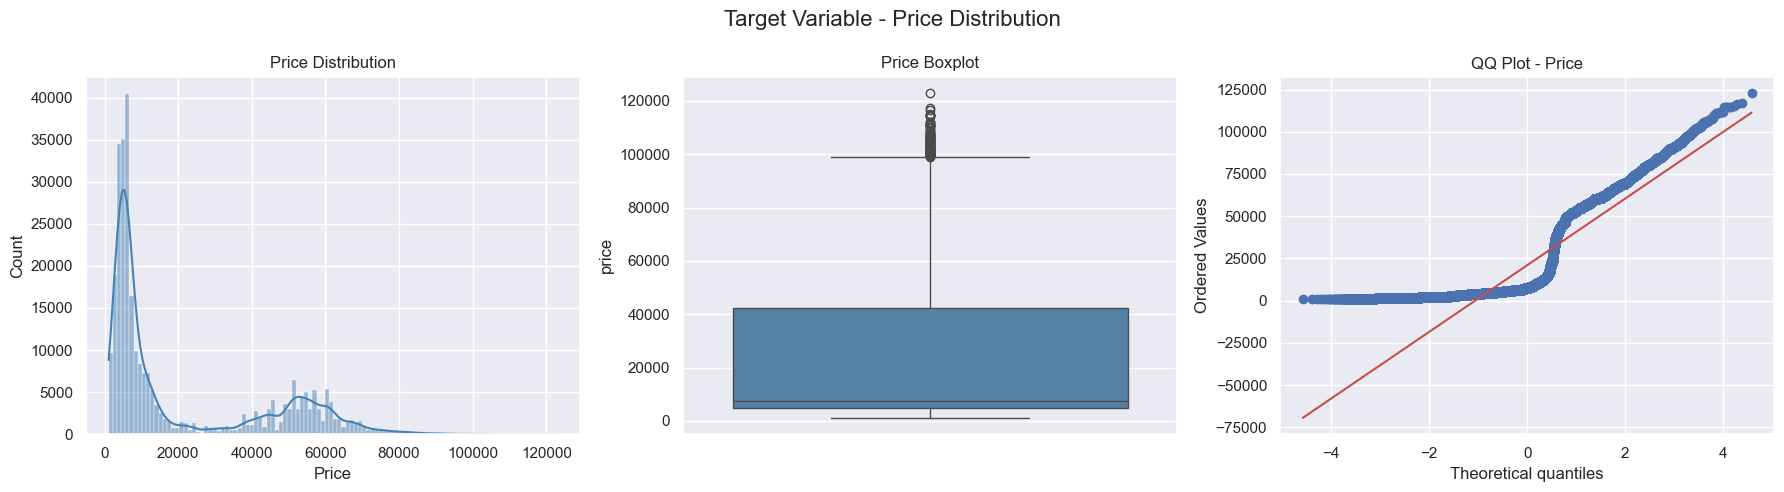

In [7]:
# ============================================================
# STEP 4: Target Variable Analysis (price)
# ============================================================

from scipy import stats

# --- Skewness & Kurtosis ---
print(f"Skewness: {df['price'].skew():.4f}")
print(f"Kurtosis: {df['price'].kurt():.4f}")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable - Price Distribution', fontsize=16)

# Distribution plot
sns.histplot(df['price'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')

# Boxplot
sns.boxplot(y=df['price'], ax=axes[1], color='steelblue')
axes[1].set_title('Price Boxplot')

# QQ Plot
stats.probplot(df['price'], dist="norm", plot=axes[2])
axes[2].set_title('QQ Plot - Price')

plt.tight_layout()
plt.show()



DURATION
Skewness : 0.6006
Kurtosis : -0.2682
Mean     : 12.2831
Median   : 11.3300
Std      : 7.1768
Min      : 0.8300
Max      : 49.8300



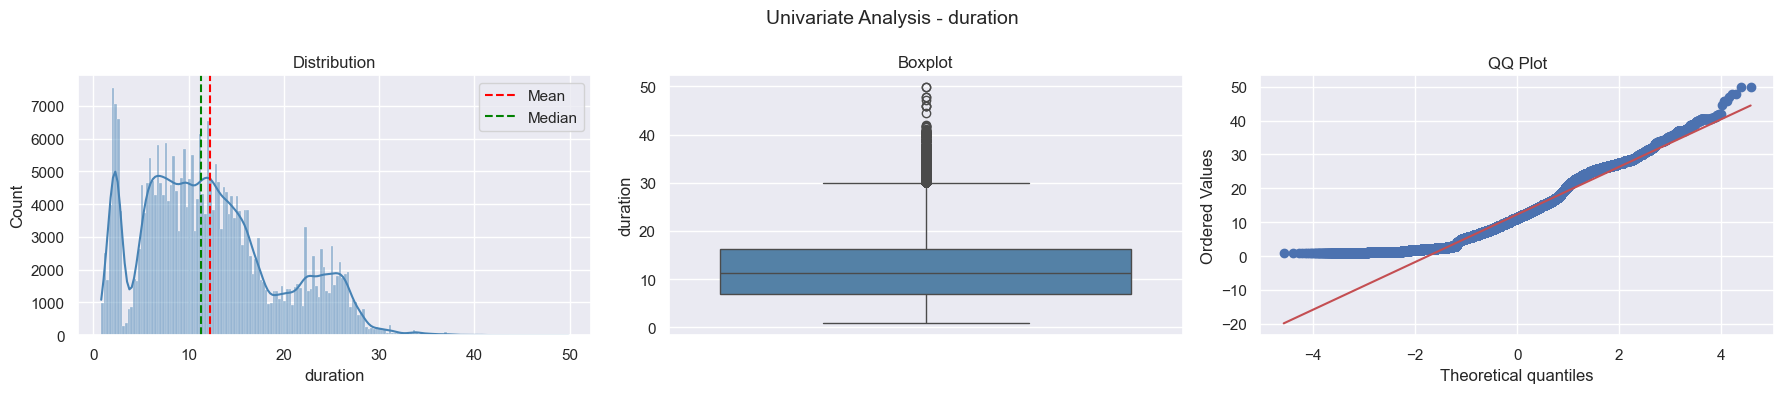

DAYS_LEFT
Skewness : -0.0365
Kurtosis : -1.1551
Mean     : 26.0046
Median   : 26.0000
Std      : 13.5572
Min      : 1.0000
Max      : 49.0000



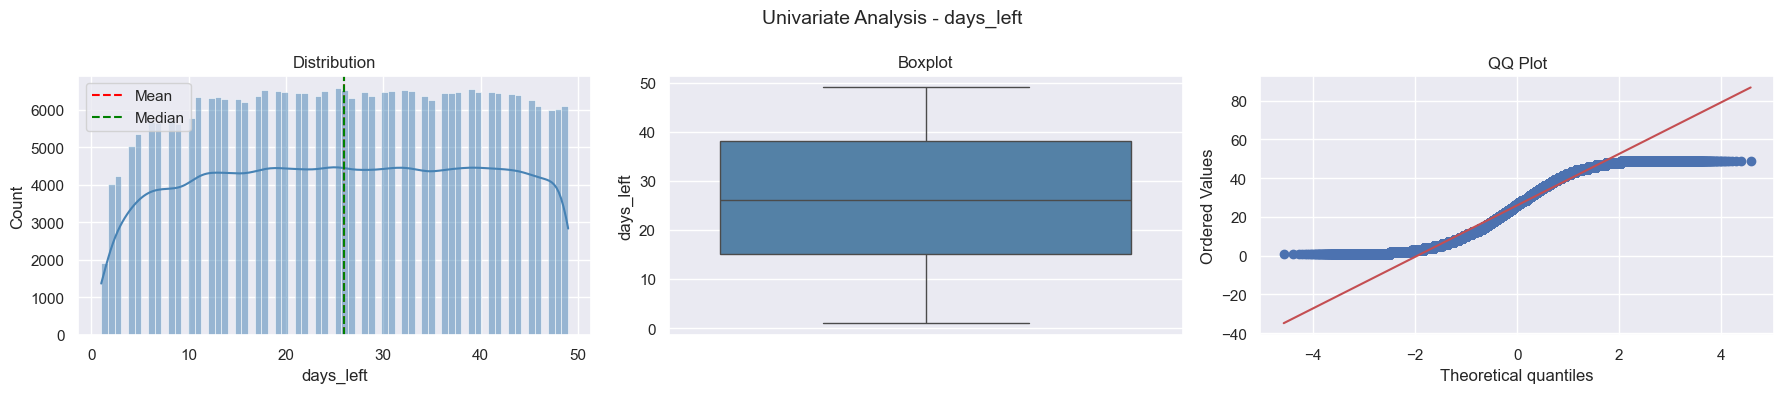

In [11]:
# ============================================================
# STEP 5: Univariate Analysis - Numerical Features
# ============================================================

num_cols = ['duration', 'days_left']

for col in num_cols:
    print(f"{'='*50}")
    print(f"{col.upper()}")
    print(f"Skewness : {df[col].skew():.4f}")
    print(f"Kurtosis : {df[col].kurt():.4f}")
    print(f"Mean     : {df[col].mean():.4f}")
    print(f"Median   : {df[col].median():.4f}")
    print(f"Std      : {df[col].std():.4f}")
    print(f"Min      : {df[col].min():.4f}")
    print(f"Max      : {df[col].max():.4f}")
    print()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'Univariate Analysis - {col}', fontsize=14)

    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('Distribution')
    axes[0].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[0].axvline(df[col].median(), color='green', linestyle='--', label='Median')
    axes[0].legend()

    # Boxplot
    sns.boxplot(y=df[col], ax=axes[1], color='steelblue')
    axes[1].set_title('Boxplot')

    # QQ Plot
    stats.probplot(df[col], dist="norm", plot=axes[2])
    axes[2].set_title('QQ Plot')

    plt.tight_layout()
    plt.show()

AIRLINE
airline
Vistara      126962
Air_India     80882
Indigo        42470
GO_FIRST      22979
AirAsia       16011
SpiceJet       8636
Name: count, dtype: int64
Cardinality: 6



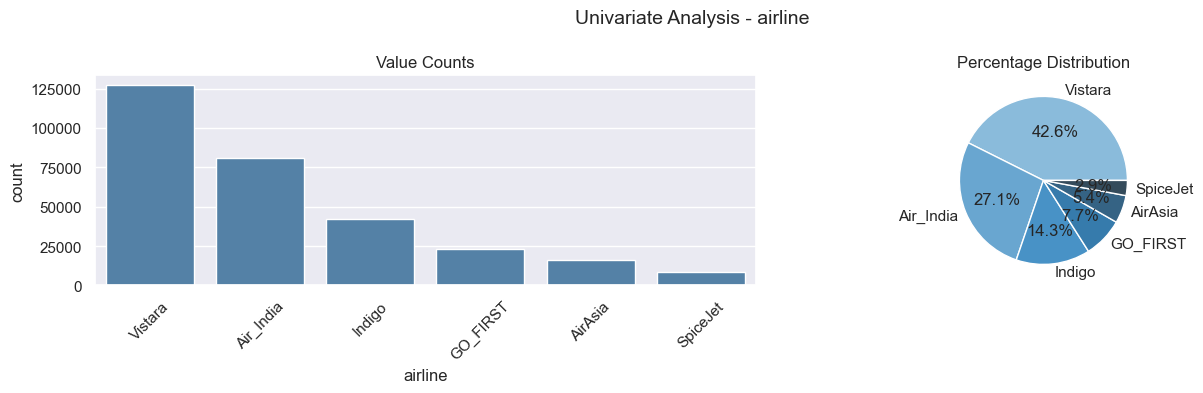

SOURCE_CITY
source_city
Delhi        60510
Mumbai       60378
Bangalore    51588
Kolkata      46240
Hyderabad    40704
Chennai      38520
Name: count, dtype: int64
Cardinality: 6



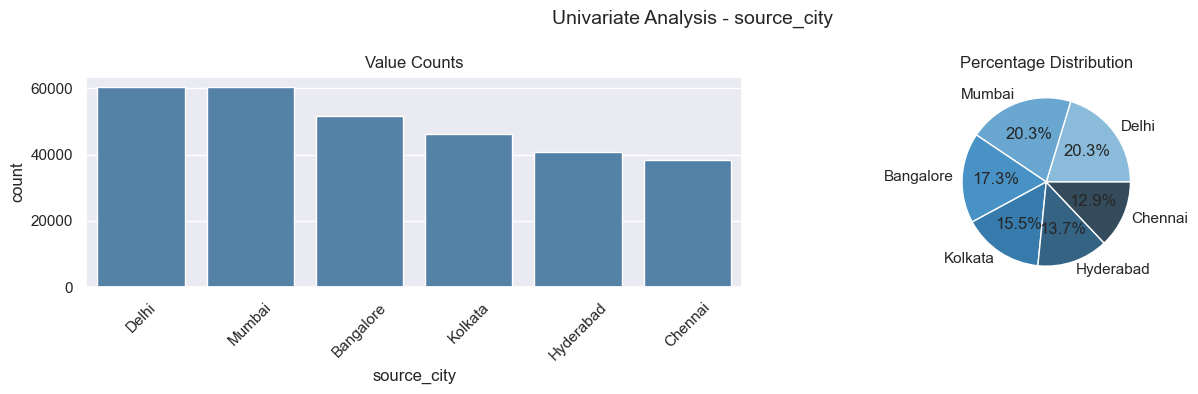

DESTINATION_CITY
destination_city
Mumbai       58691
Delhi        56749
Bangalore    50634
Kolkata      49202
Hyderabad    42558
Chennai      40106
Name: count, dtype: int64
Cardinality: 6



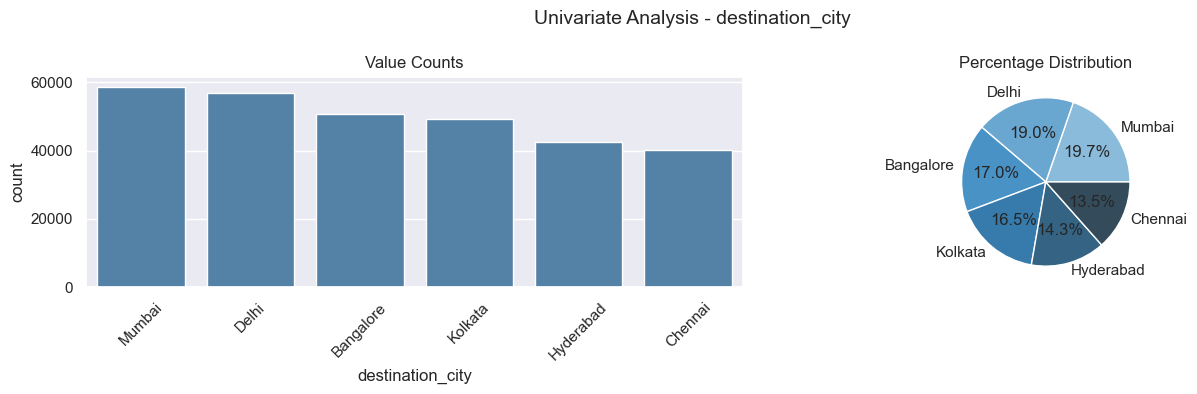

DEPARTURE_TIME
departure_time
Morning          70824
Early_Morning    66250
Evening          64428
Night            47651
Afternoon        47485
Late_Night        1302
Name: count, dtype: int64
Cardinality: 6



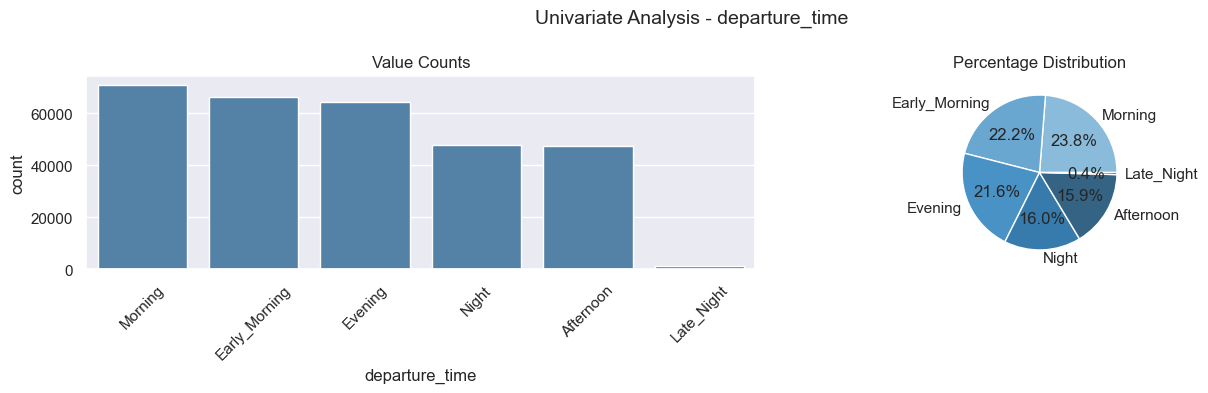

ARRIVAL_TIME
arrival_time
Night            90712
Evening          77960
Morning          62054
Afternoon        38030
Early_Morning    15333
Late_Night       13851
Name: count, dtype: int64
Cardinality: 6



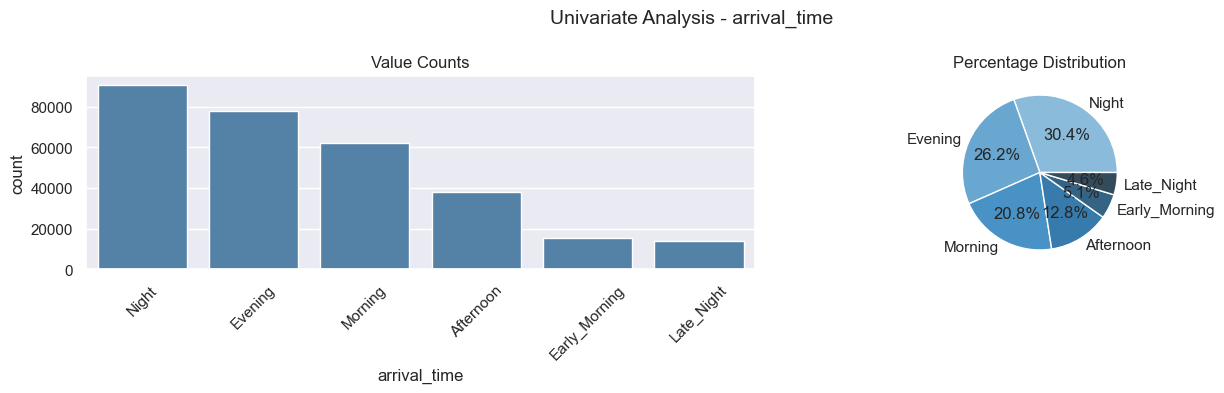

STOPS
stops
one            250314
zero            34341
two_or_more     13285
Name: count, dtype: int64
Cardinality: 3



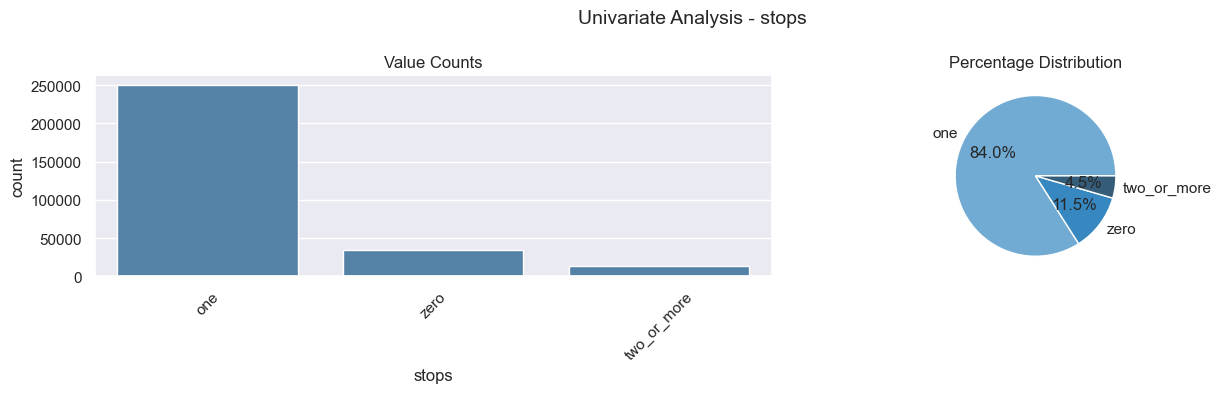

CLASS
class
Economy     204767
Business     93173
Name: count, dtype: int64
Cardinality: 2



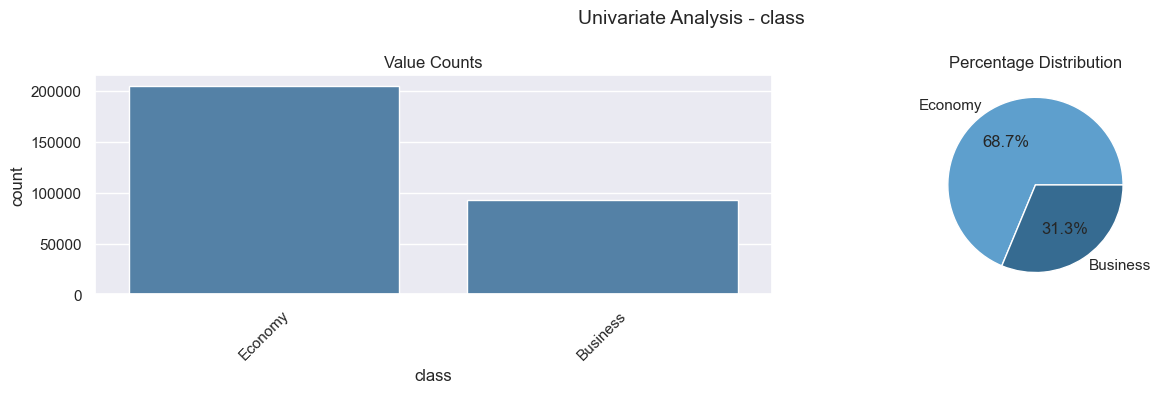

In [15]:
# ============================================================
# STEP 6: Univariate Analysis - Categorical Features
# ============================================================

cat_cols = ['airline', 'source_city', 'destination_city', 
            'departure_time', 'arrival_time', 'stops', 'class']

for col in cat_cols:
    print(f"{'='*50}")
    print(f"{col.upper()}")
    print(df[col].value_counts())
    print(f"Cardinality: {df[col].nunique()}")
    print()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Univariate Analysis - {col}', fontsize=14)

    # Value counts bar chart
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[0], color='steelblue')
    axes[0].set_title('Value Counts')
    axes[0].set_xlabel(col)
    axes[0].tick_params(axis='x', rotation=45)

    # Percentage pie chart
    df[col].value_counts().plot.pie(
        autopct='%1.1f%%',
        ax=axes[1],
        colors=sns.color_palette('Blues_d', df[col].nunique())
    )
    axes[1].set_title('Percentage Distribution')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

DURATION
Q1          : 6.92
Q3          : 16.17
IQR         : 9.25
Lower Bound : -6.96
Upper Bound : 30.05
Outliers    : 2226 (0.75%)

DAYS_LEFT
Q1          : 15.00
Q3          : 38.00
IQR         : 23.00
Lower Bound : -19.50
Upper Bound : 72.50
Outliers    : 0 (0.00%)

PRICE
Q1          : 4792.00
Q3          : 42521.00
IQR         : 37729.00
Lower Bound : -51801.50
Upper Bound : 99114.50
Outliers    : 123 (0.04%)



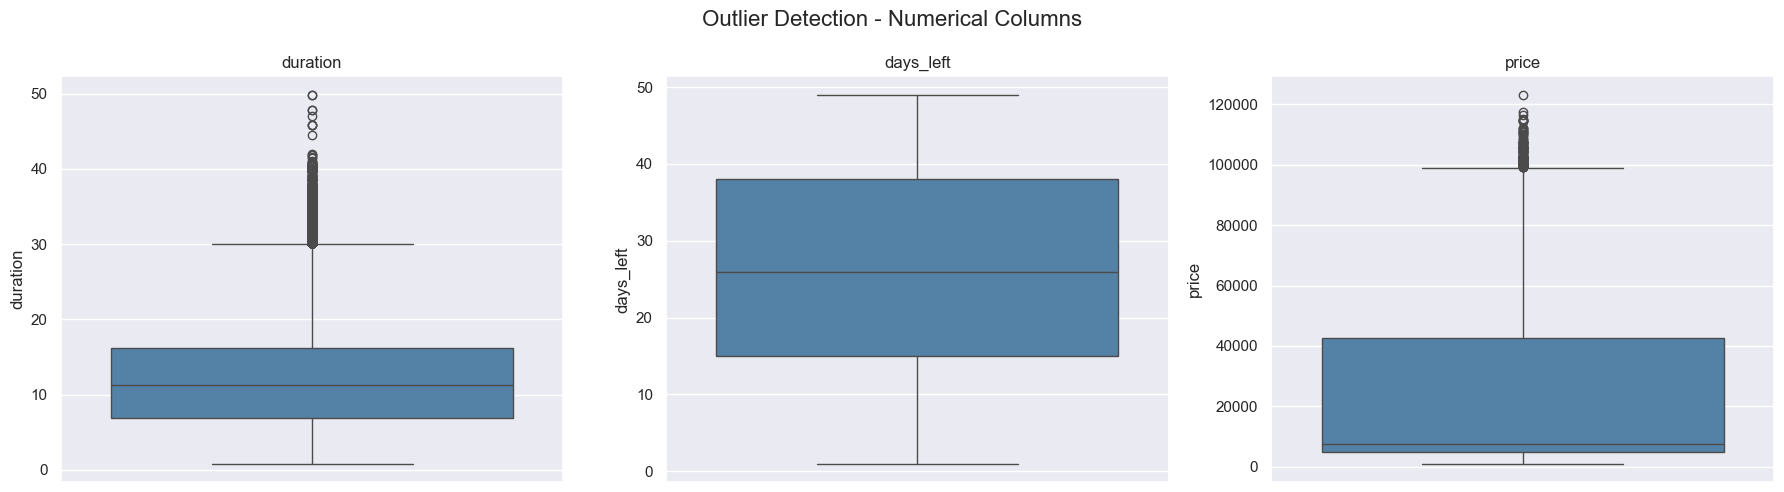

In [16]:
# ============================================================
# STEP 7: Outlier Detection
# ============================================================

num_cols = ['duration', 'days_left', 'price']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_pct = (len(outliers) / len(df)) * 100

    print(f"{'='*50}")
    print(f"{col.upper()}")
    print(f"Q1          : {Q1:.2f}")
    print(f"Q3          : {Q3:.2f}")
    print(f"IQR         : {IQR:.2f}")
    print(f"Lower Bound : {lower:.2f}")
    print(f"Upper Bound : {upper:.2f}")
    print(f"Outliers    : {len(outliers)} ({outlier_pct:.2f}%)")
    print()

# --- Visualize ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Outlier Detection - Numerical Columns', fontsize=16)

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

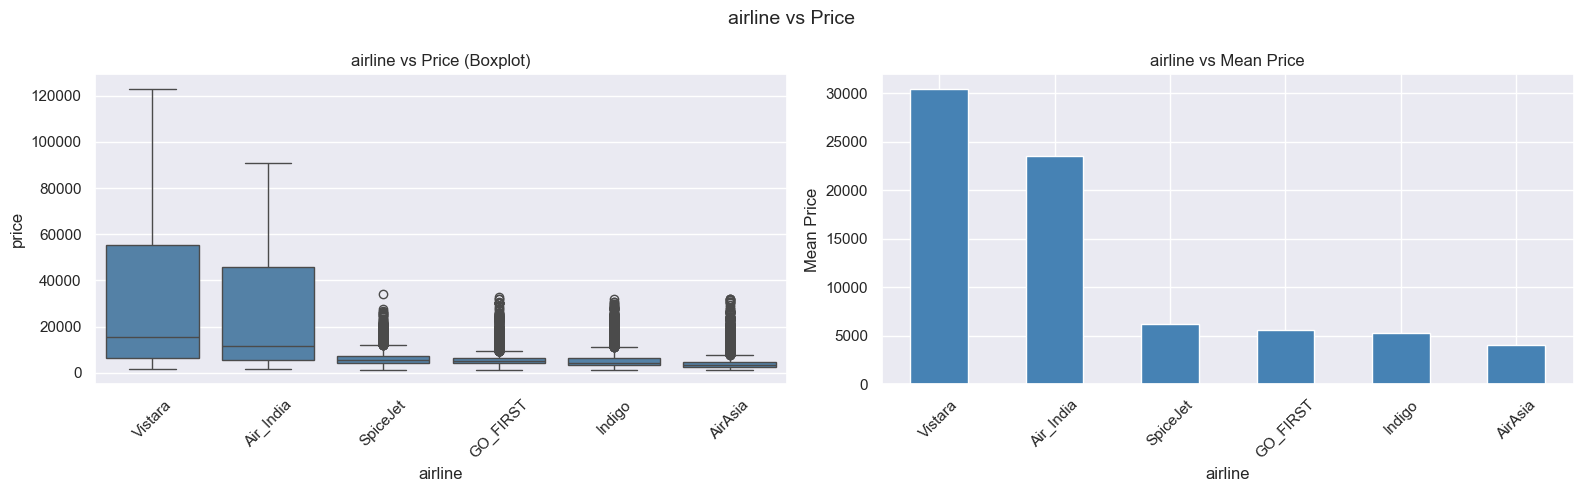

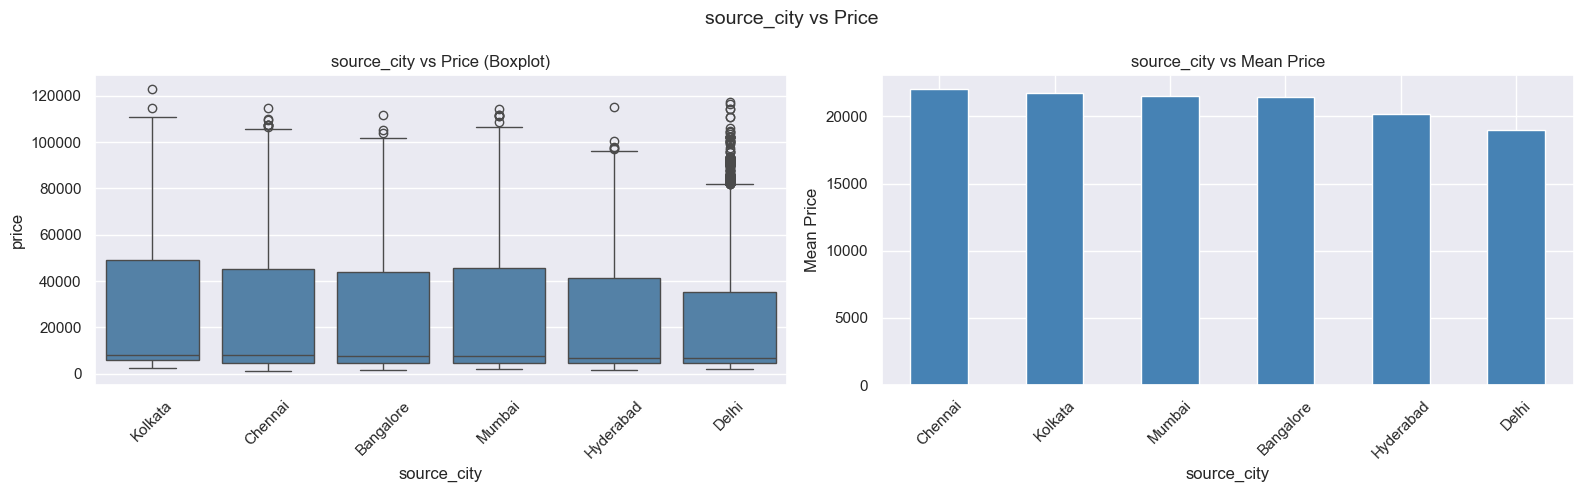

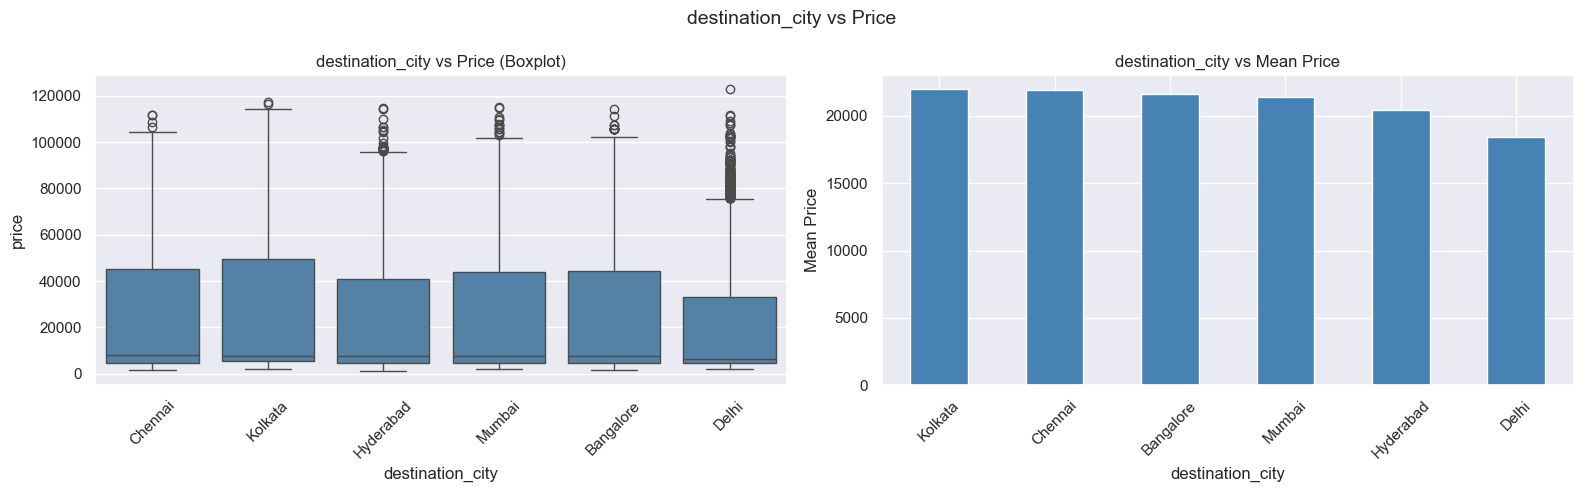

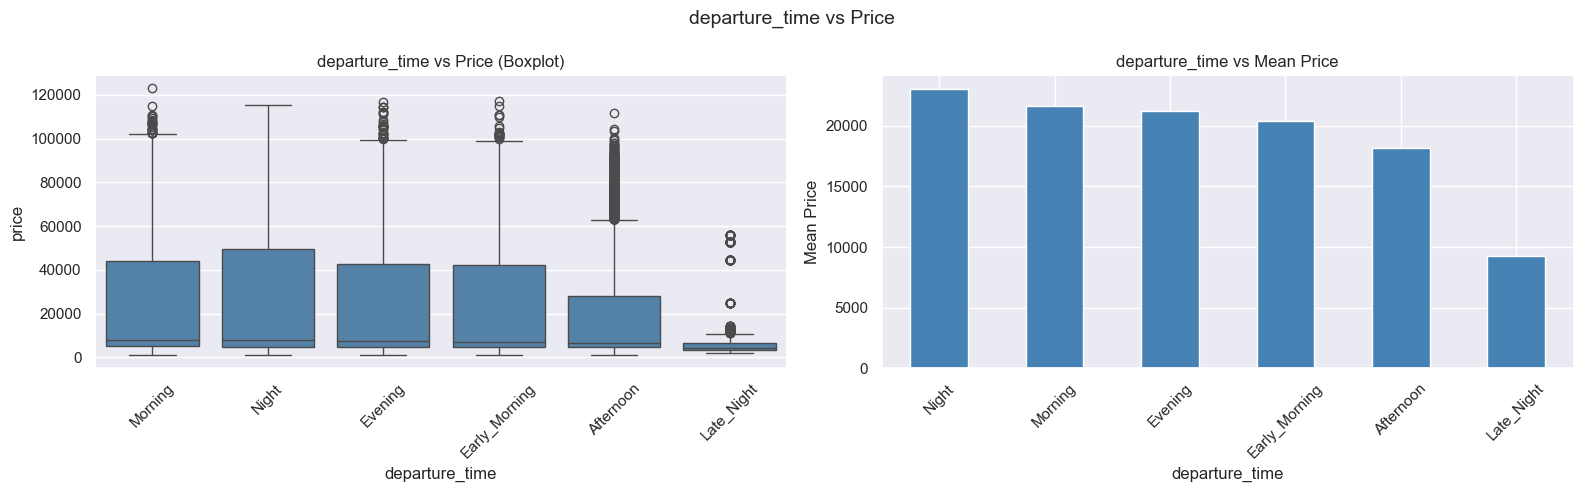

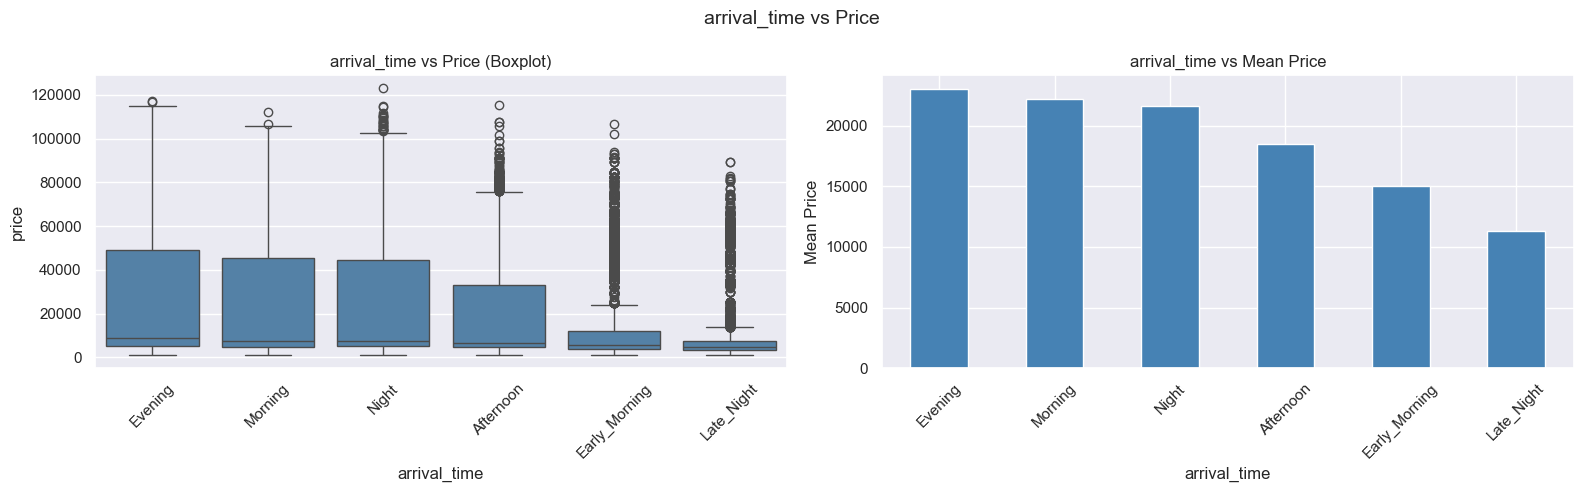

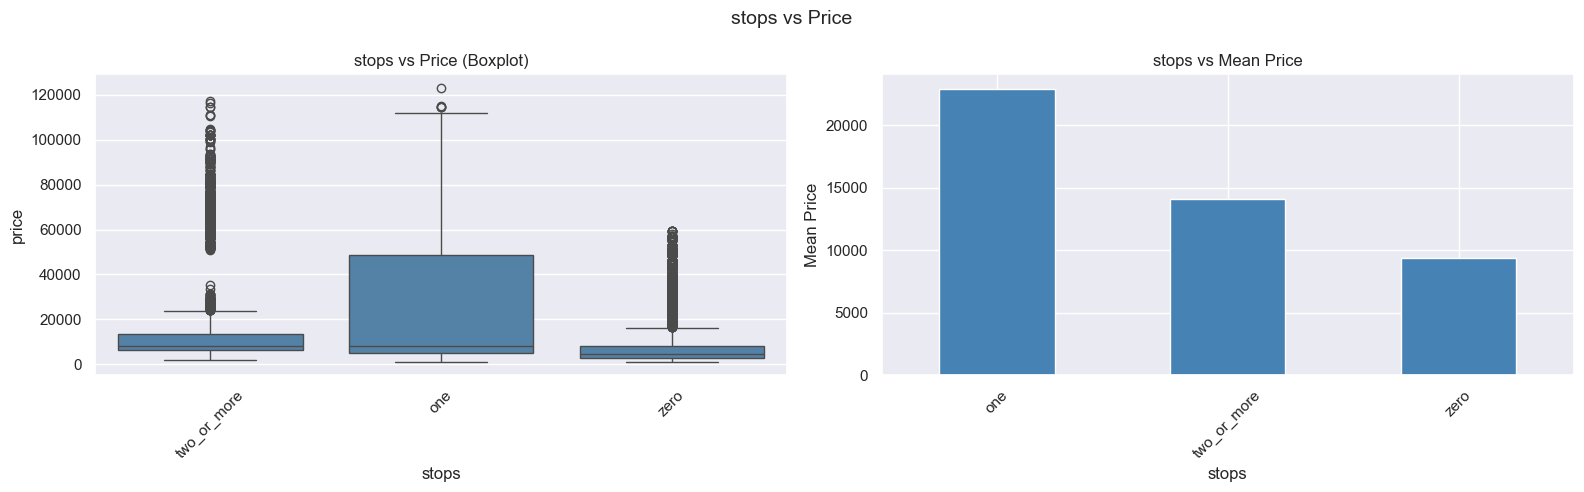

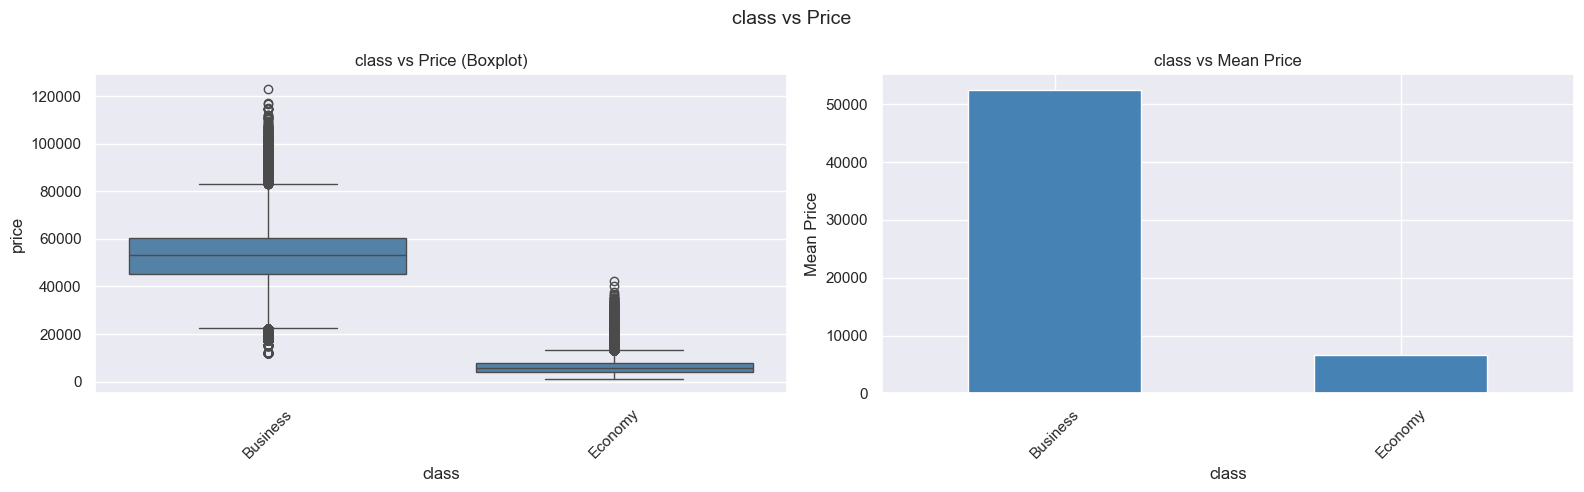

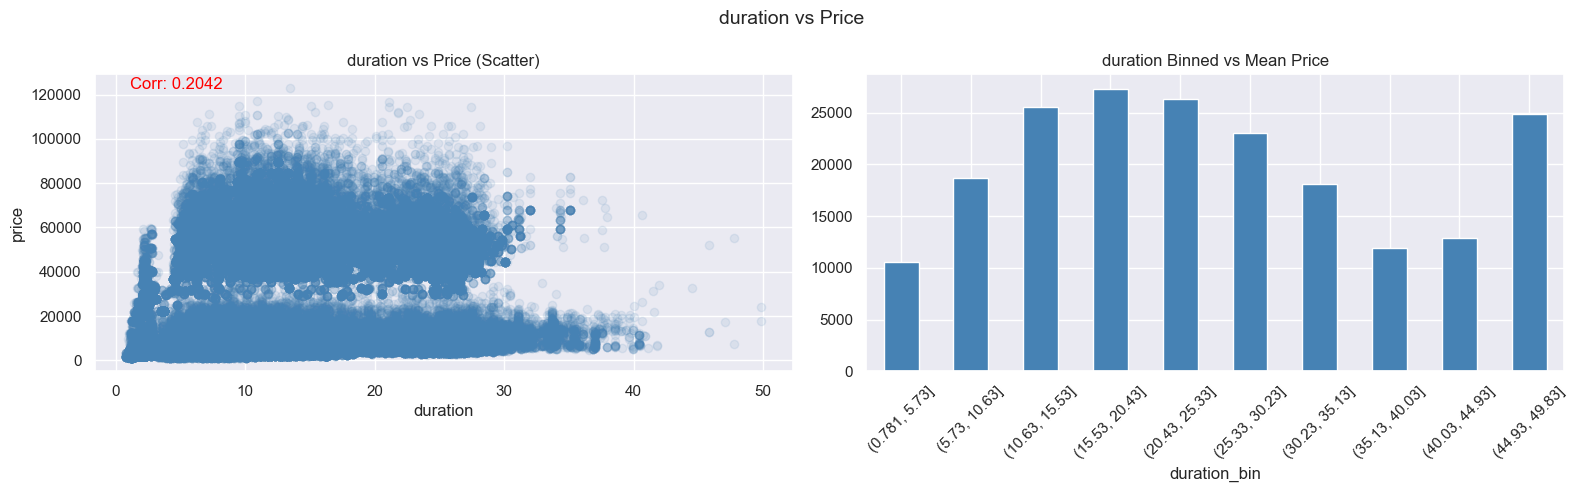

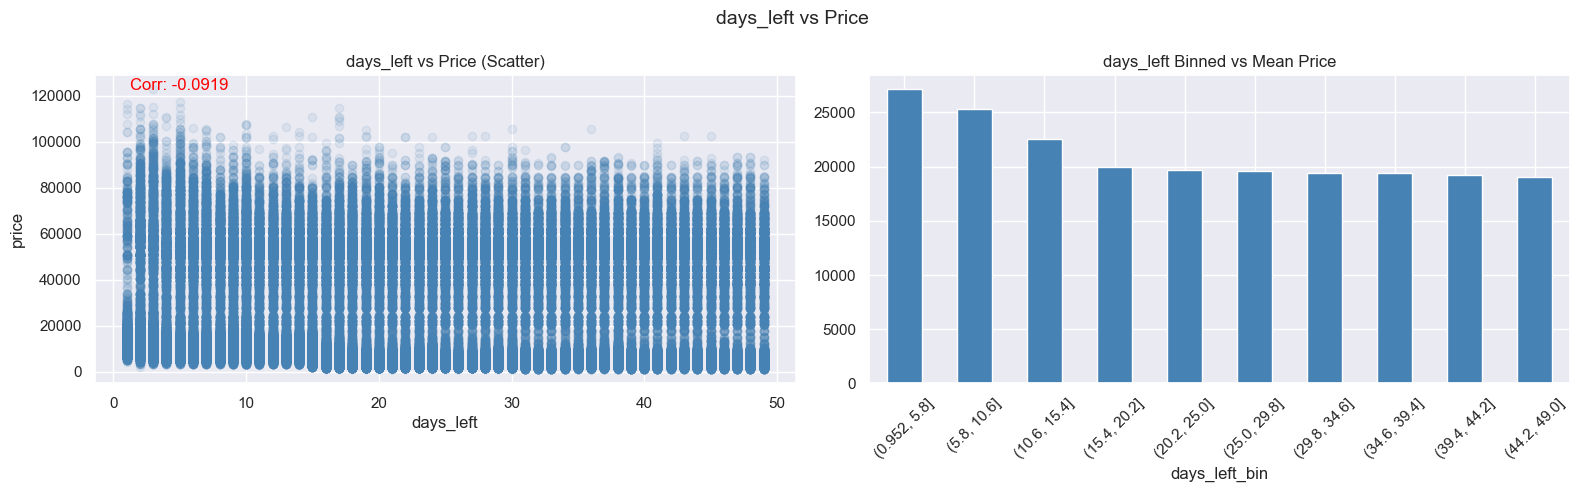

In [4]:
# ============================================================
# STEP 8: Bivariate Analysis - Features vs Price
# ============================================================

# --- Categorical Features vs Price ---
cat_cols = ['airline', 'source_city', 'destination_city',
            'departure_time', 'arrival_time', 'stops', 'class']

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'{col} vs Price', fontsize=14)

    # Boxplot
    order = df.groupby(col)['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='price', order=order, ax=axes[0], color='steelblue')
    axes[0].set_title(f'{col} vs Price (Boxplot)')
    axes[0].tick_params(axis='x', rotation=45)

    # Mean price bar chart
    mean_price = df.groupby(col)['price'].mean().sort_values(ascending=False)
    mean_price.plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title(f'{col} vs Mean Price')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Mean Price')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# --- Numerical Features vs Price ---
num_cols = ['duration', 'days_left']

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'{col} vs Price', fontsize=14)

    # Scatter plot
    axes[0].scatter(df[col], df['price'], alpha=0.1, color='steelblue')
    axes[0].set_title(f'{col} vs Price (Scatter)')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('price')

    # Correlation
    corr = df[col].corr(df['price'])
    axes[0].annotate(f'Corr: {corr:.4f}', xy=(0.05, 0.95),
                     xycoords='axes fraction', fontsize=12, color='red')

    # Binned mean price
    df[f'{col}_bin'] = pd.cut(df[col], bins=10)
    bin_mean = df.groupby(f'{col}_bin')['price'].mean()
    bin_mean.plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title(f'{col} Binned vs Mean Price')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Drop bin column
    df.drop(columns=[f'{col}_bin'], inplace=True)

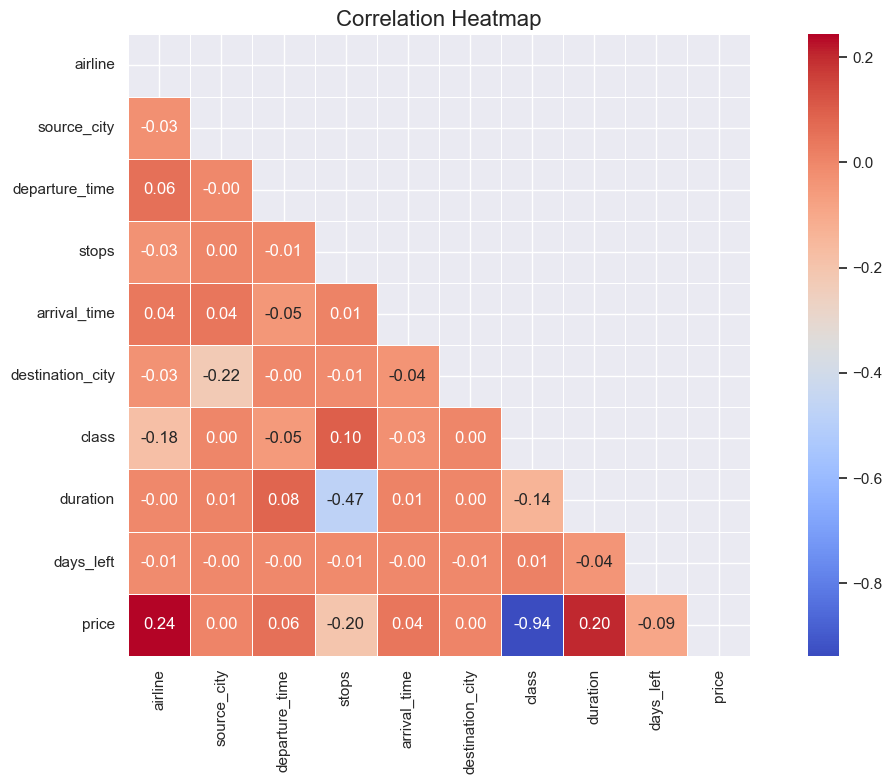

Correlation with Price (sorted):
airline             0.243358
duration            0.204222
departure_time      0.058319
arrival_time        0.042043
destination_city    0.004795
source_city         0.004594
days_left          -0.091949
stops              -0.202620
class              -0.937860
Name: price, dtype: float64

Variance Inflation Factor (VIF):
            Feature       VIF
7          duration  4.113876
8         days_left  3.976790
4      arrival_time  3.684550
0           airline  3.393124
1       source_city  2.927766
5  destination_city  2.885337
6             class  2.849370
2    departure_time  2.779427
3             stops  1.426614


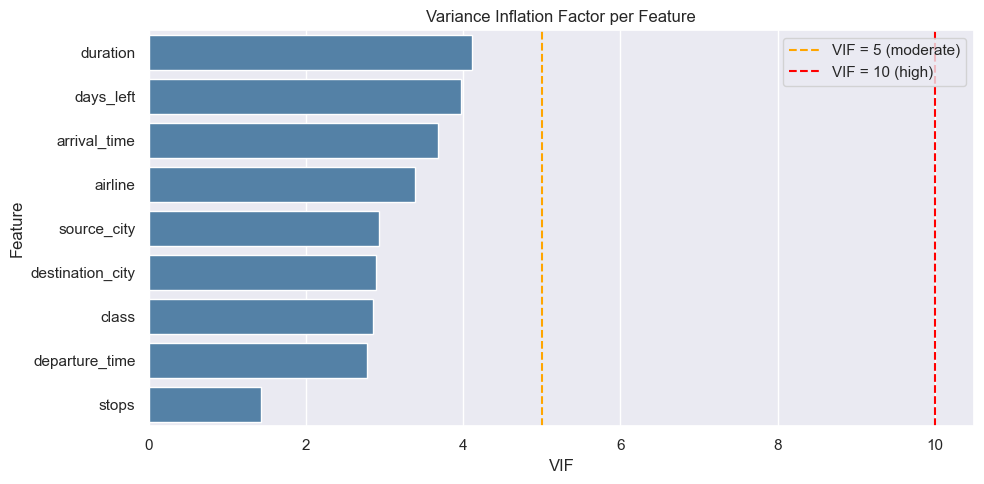

In [6]:
# ============================================================
# STEP 9: Correlation Heatmap & VIF
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

# --- Encode categoricals for correlation & VIF ---
df_encoded = df.copy()
le = LabelEncoder()
cat_cols = ['airline', 'source_city', 'destination_city',
            'departure_time', 'arrival_time', 'stops', 'class']

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# --- Correlation Heatmap ---
plt.figure(figsize=(12, 8))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# --- Correlation with Target ---
print("Correlation with Price (sorted):")
print(corr_matrix['price'].drop('price').sort_values(ascending=False))

# --- VIF ---
print("\nVariance Inflation Factor (VIF):")
features = df_encoded.drop(columns=['price'])
vif_data = pd.DataFrame()
vif_data['Feature'] = features.columns
vif_data['VIF'] = [variance_inflation_factor(features.values, i)
                   for i in range(features.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

# --- VIF Bar Plot ---
plt.figure(figsize=(10, 5))
sns.barplot(data=vif_data, x='VIF', y='Feature', color='steelblue')
plt.axvline(x=5, color='orange', linestyle='--', label='VIF = 5 (moderate)')
plt.axvline(x=10, color='red', linestyle='--', label='VIF = 10 (high)')
plt.title('Variance Inflation Factor per Feature')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# EDA SUMMARY
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║                    EDA SUMMARY                               ║
╚══════════════════════════════════════════════════════════════╝

📦 DATASET
─────────────────────────────────────────────────────────────
- Original shape  : (300153, 12)
- After cleaning  : (297940, 10)
- Removed         : 2213 duplicate rows (0.74%)
- Dropped columns : 'Unnamed: 0', 'flight' (non-predictive)

🧹 DATA QUALITY
─────────────────────────────────────────────────────────────
- Missing values       : None ✅
- Negative values      : None ✅
- Source == Destination: None ✅
- Outliers (duration)  : 2226 (0.75%) → kept (real long routes)
- Outliers (price)     : 123  (0.04%) → kept (premium tickets)

🎯 TARGET VARIABLE (price)
─────────────────────────────────────────────────────────────
- Skewness    : 1.05 (moderate right skew)
- Kurtosis    : -0.41 (platykurtic — bimodal shape)
- Bimodal distribution driven by Economy vs Business class
- Mean (₹20,889) >> Median (₹7,425) — large gap
- Log transformation to be applied in preprocessing

📊 FEATURE INSIGHTS
─────────────────────────────────────────────────────────────
- class          : Strongest predictor | Business ~9x Economy
- airline        : Vistara/Air_India operate Business → higher prices
- stops          : 'one' stop costlier than 'zero' (budget carriers fly direct)
- departure_time : Night/Morning most expensive | Late_Night cheapest
- arrival_time   : Evening/Morning most expensive | Late_Night cheapest
- duration       : Weak positive correlation (0.20) with price
- days_left      : Last 5 days = spike in price, then flattens (-0.09)
- source_city    : Minimal impact on price (0.00)
- destination_city: Minimal impact on price (0.00)

🔗 MULTICOLLINEARITY
─────────────────────────────────────────────────────────────
- All VIF values < 5 → No multicollinearity issue ✅
- Notable feature-feature correlation:
  - duration vs stops : -0.47 (acceptable)
  - All others        : near zero

⚙️ PREPROCESSING DECISIONS
─────────────────────────────────────────────────────────────
- Log transform      : price (target variable)
- Encoding           : One-Hot Encode all categorical columns
- Scaling            : StandardScaler on duration, days_left
- Late_Night (0.4%)  : Monitor during encoding — consider merging with Night
- Keep all features  : No drops needed based on EDA findings
""")


╔══════════════════════════════════════════════════════════════╗
║                    EDA SUMMARY                               ║
╚══════════════════════════════════════════════════════════════╝

📦 DATASET
─────────────────────────────────────────────────────────────
- Original shape  : (300153, 12)
- After cleaning  : (297940, 10)
- Removed         : 2213 duplicate rows (0.74%)
- Dropped columns : 'Unnamed: 0', 'flight' (non-predictive)

🧹 DATA QUALITY
─────────────────────────────────────────────────────────────
- Missing values       : None ✅
- Negative values      : None ✅
- Source == Destination: None ✅
- Outliers (duration)  : 2226 (0.75%) → kept (real long routes)
- Outliers (price)     : 123  (0.04%) → kept (premium tickets)

🎯 TARGET VARIABLE (price)
─────────────────────────────────────────────────────────────
- Skewness    : 1.05 (moderate right skew)
- Kurtosis    : -0.41 (platykurtic — bimodal shape)
- Bimodal distribution driven by Economy vs Business class
- Mean (₹20,8

In [1]:
# Imports for error analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tensorflow.keras.models import load_model

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the trained ANN
ann_model = load_model('data/processed/ann_model.keras')

# Load preprocessed test data
X_test = pd.read_csv('data/processed/X_test.csv')
y_test_log = pd.read_csv('data/processed/y_test.csv').squeeze()

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test_log.shape}")

X_test shape: (59588, 29)
y_test shape: (59588,)


In [3]:
# Predict in log space
y_pred_log = ann_model.predict(X_test, verbose=0).flatten()

# Inverse-transform both predictions and actuals back to rupees
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test_log)

# Compute residuals (signed) and absolute errors
residuals = y_true - y_pred
abs_errors = np.abs(residuals)

# Recover the original 'class' label from the encoded 0/1 column
# (0 = Economy, 1 = Business, per our OrdinalEncoder order)
class_label = X_test['class'].map({0.0: 'Economy', 1.0: 'Business'})

# Assemble into one tidy dataframe for plotting
analysis_df = pd.DataFrame({
    'actual_price': y_true.values,
    'predicted_price': y_pred,
    'residual': residuals.values,
    'abs_error': abs_errors.values,
    'class': class_label.values,
})

print(analysis_df.head())
print(f"\nShape: {analysis_df.shape}")
print(f"\nMean absolute error: ₹{analysis_df['abs_error'].mean():,.2f}")
print(f"Mean residual (should be ~0 if unbiased): ₹{analysis_df['residual'].mean():,.2f}")

   actual_price  predicted_price      residual     abs_error     class
0       24120.0     11061.534180  13058.465820  13058.465820   Economy
1       54684.0     51545.164062   3138.835938   3138.835938  Business
2       41314.0     43784.226562  -2470.226562   2470.226562  Business
3       44280.0     40624.226562   3655.773437   3655.773437  Business
4       60508.0     59698.667969    809.332031    809.332031  Business

Shape: (59588, 5)

Mean absolute error: ₹2,174.98
Mean residual (should be ~0 if unbiased): ₹487.94


In [4]:
# Predict in log space
y_pred_log = ann_model.predict(X_test, verbose=0).flatten()

# Inverse-transform both predictions and actuals back to rupees
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test_log)

# Compute residuals (signed) and absolute errors
residuals = y_true - y_pred
abs_errors = np.abs(residuals)

# Recover the original 'class' label from the encoded 0/1 column
# (0 = Economy, 1 = Business, per our OrdinalEncoder order)
class_label = X_test['class'].map({0.0: 'Economy', 1.0: 'Business'})

# Assemble into one tidy dataframe for plotting
analysis_df = pd.DataFrame({
    'actual_price': y_true.values,
    'predicted_price': y_pred,
    'residual': residuals.values,
    'abs_error': abs_errors.values,
    'class': class_label.values,
})

print(analysis_df.head())
print(f"\nShape: {analysis_df.shape}")
print(f"\nMean absolute error: ₹{analysis_df['abs_error'].mean():,.2f}")
print(f"Mean residual (should be ~0 if unbiased): ₹{analysis_df['residual'].mean():,.2f}")

   actual_price  predicted_price      residual     abs_error     class
0       24120.0     11061.534180  13058.465820  13058.465820   Economy
1       54684.0     51545.164062   3138.835938   3138.835938  Business
2       41314.0     43784.226562  -2470.226562   2470.226562  Business
3       44280.0     40624.226562   3655.773437   3655.773437  Business
4       60508.0     59698.667969    809.332031    809.332031  Business

Shape: (59588, 5)

Mean absolute error: ₹2,174.98
Mean residual (should be ~0 if unbiased): ₹487.94


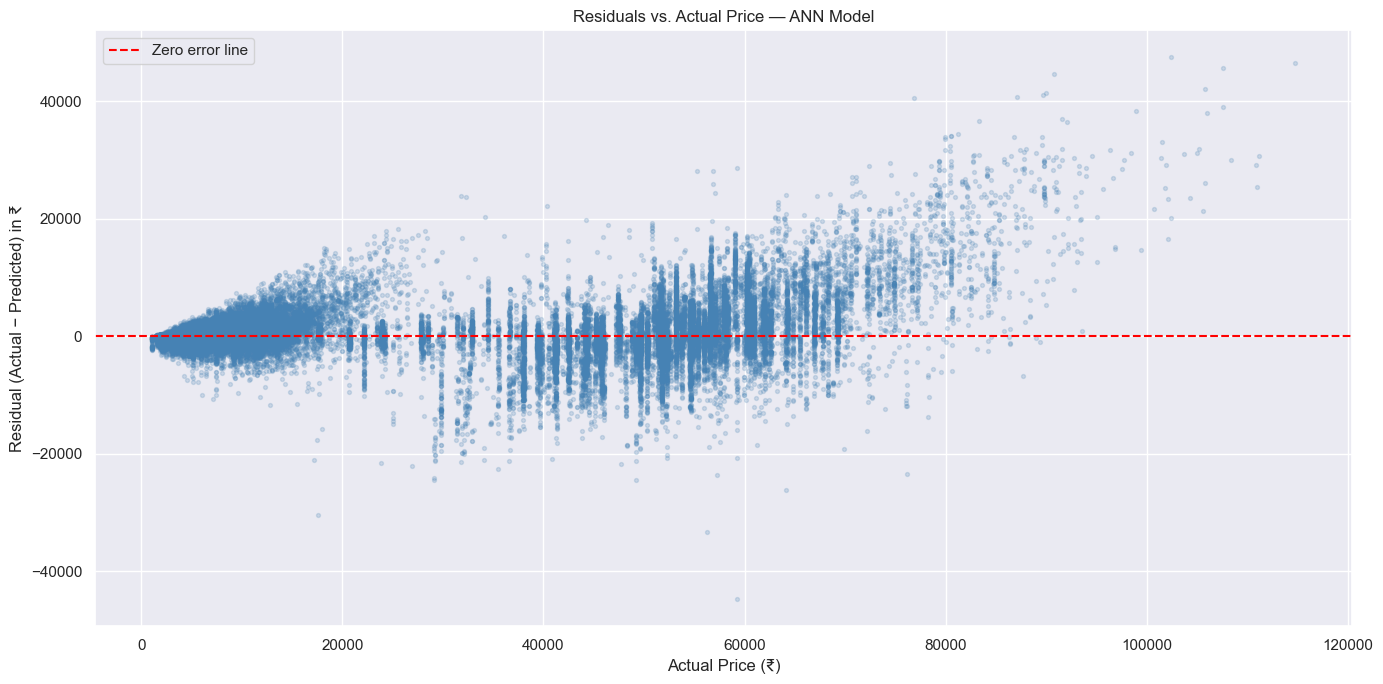

In [5]:
plt.figure(figsize=(14, 7))
plt.scatter(
    analysis_df['actual_price'],
    analysis_df['residual'],
    alpha=0.2,
    s=8,
    color='steelblue',
)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error line')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Residual (Actual − Predicted) in ₹')
plt.title('Residuals vs. Actual Price — ANN Model')
plt.legend()
plt.tight_layout()
plt.show()

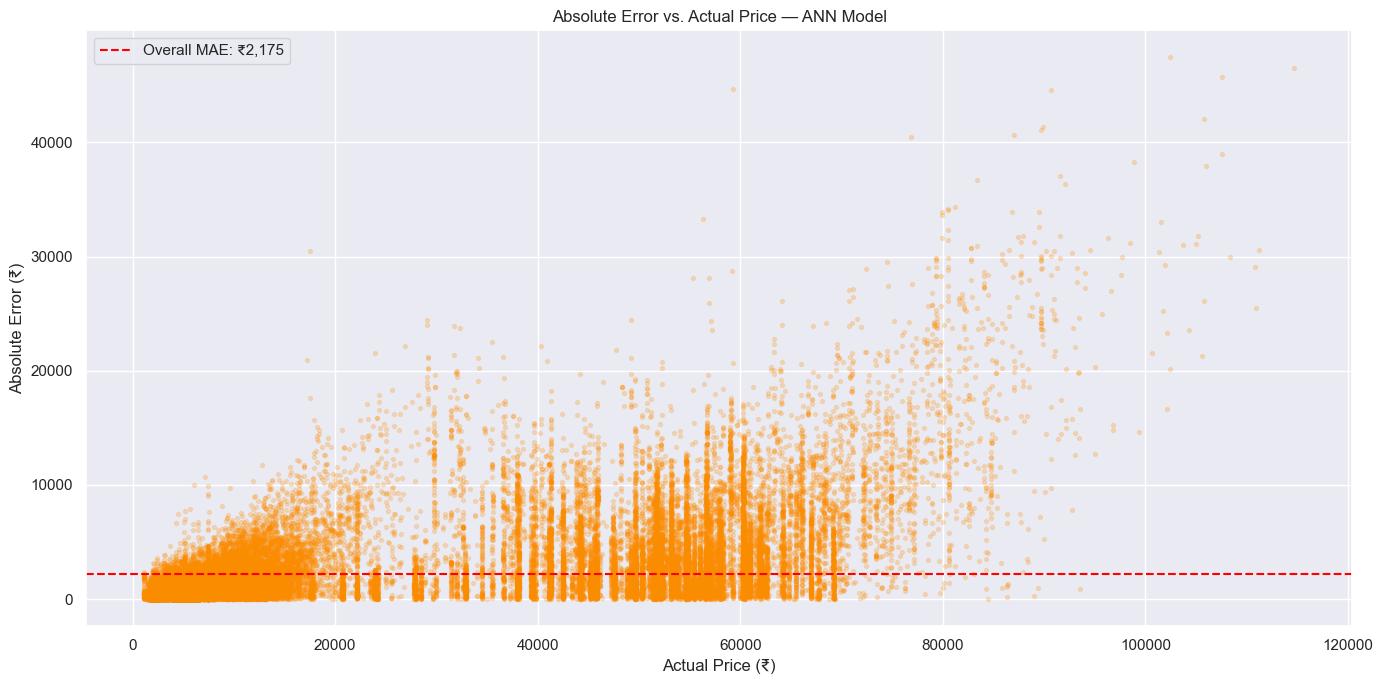

In [6]:
plt.figure(figsize=(14, 7))
plt.scatter(
    analysis_df['actual_price'],
    analysis_df['abs_error'],
    alpha=0.2,
    s=8,
    color='darkorange',
)
plt.axhline(analysis_df['abs_error'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Overall MAE: ₹{analysis_df["abs_error"].mean():,.0f}')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Absolute Error (₹)')
plt.title('Absolute Error vs. Actual Price — ANN Model')
plt.legend()
plt.tight_layout()
plt.show()

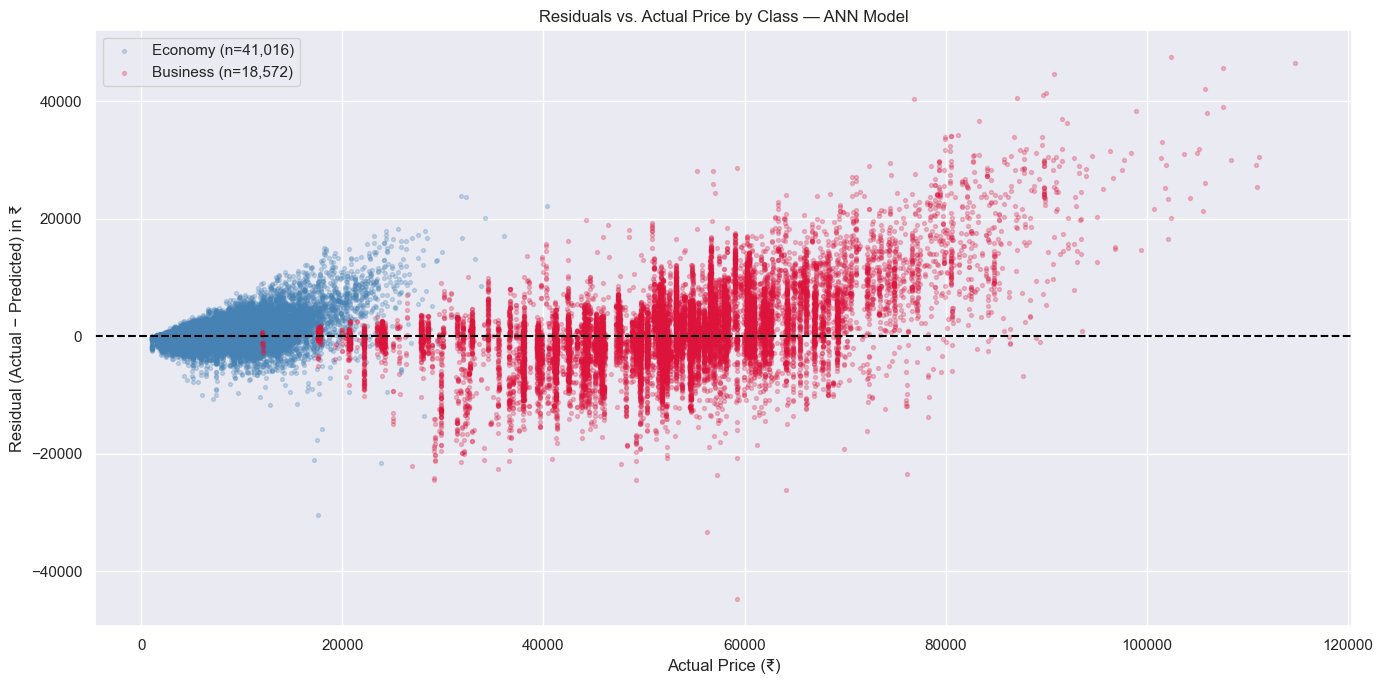

In [7]:
plt.figure(figsize=(14, 7))

for class_name, color in [('Economy', 'steelblue'), ('Business', 'crimson')]:
    subset = analysis_df[analysis_df['class'] == class_name]
    plt.scatter(
        subset['actual_price'],
        subset['residual'],
        alpha=0.25,
        s=8,
        color=color,
        label=f'{class_name} (n={len(subset):,})',
    )

plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Actual Price (₹)')
plt.ylabel('Residual (Actual − Predicted) in ₹')
plt.title('Residuals vs. Actual Price by Class — ANN Model')
plt.legend()
plt.tight_layout()
plt.show()

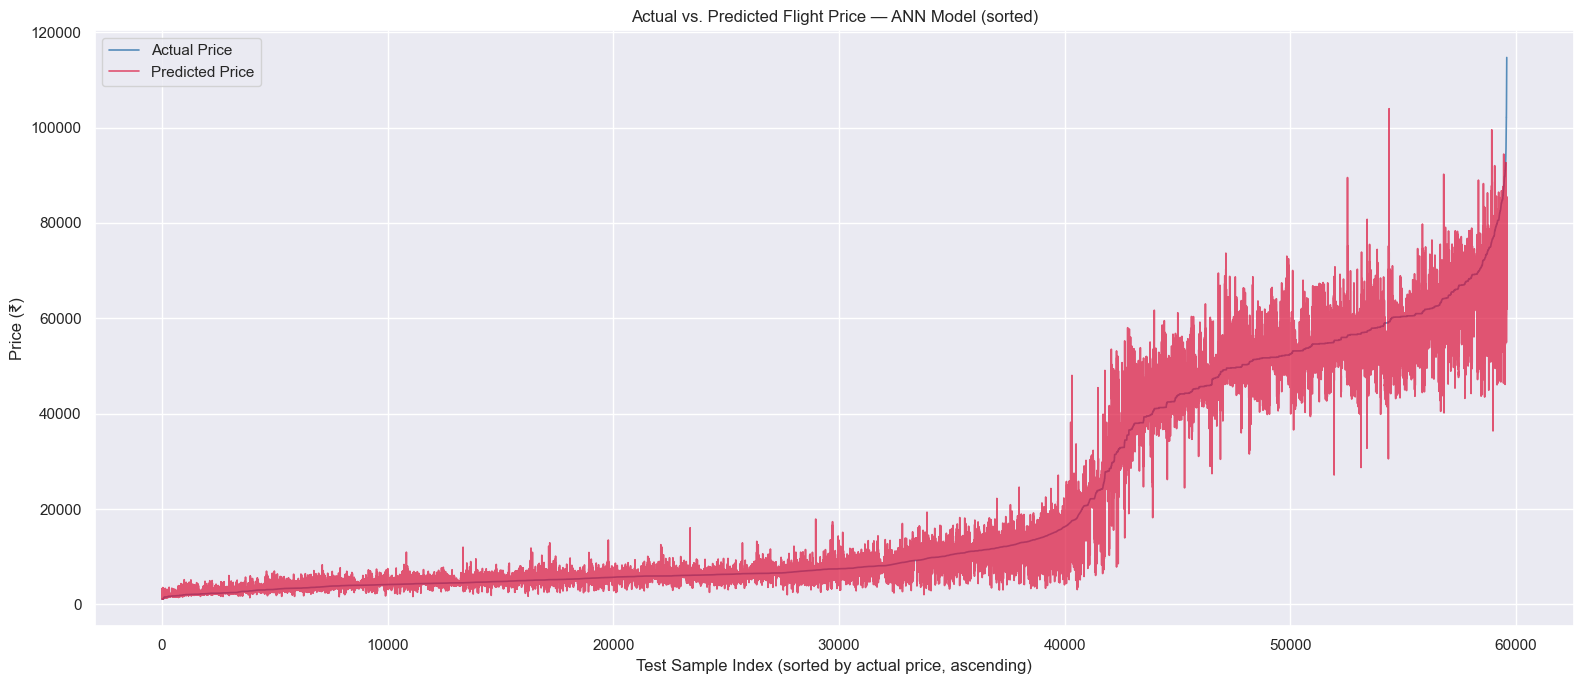

In [8]:
# Sort the entire analysis_df by actual price, ascending
sorted_df = analysis_df.sort_values('actual_price').reset_index(drop=True)

plt.figure(figsize=(16, 7))
plt.plot(sorted_df.index, sorted_df['actual_price'],
         label='Actual Price', color='steelblue', linewidth=1.2, alpha=0.9)
plt.plot(sorted_df.index, sorted_df['predicted_price'],
         label='Predicted Price', color='crimson', linewidth=1.2, alpha=0.7)

plt.xlabel('Test Sample Index (sorted by actual price, ascending)')
plt.ylabel('Price (₹)')
plt.title('Actual vs. Predicted Flight Price — ANN Model (sorted)')
plt.legend()
plt.tight_layout()
plt.show()

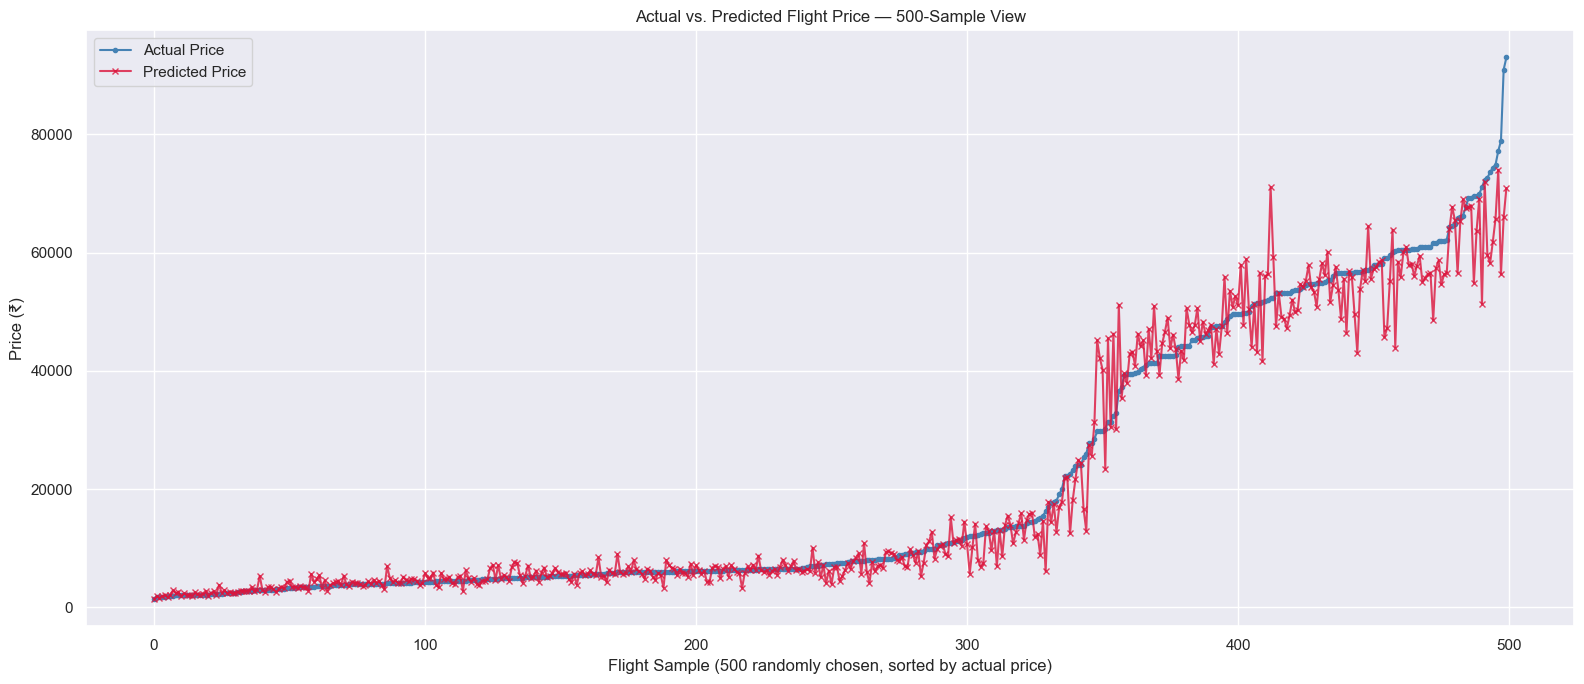

In [9]:
# Take a random sample of 500 flights, sorted by actual price
sample_df = analysis_df.sample(n=500, random_state=42).sort_values('actual_price').reset_index(drop=True)

plt.figure(figsize=(16, 7))
plt.plot(sample_df.index, sample_df['actual_price'],
         label='Actual Price', color='steelblue', linewidth=1.5, marker='o', markersize=3)
plt.plot(sample_df.index, sample_df['predicted_price'],
         label='Predicted Price', color='crimson', linewidth=1.5, marker='x', markersize=4, alpha=0.8)

plt.xlabel('Flight Sample (500 randomly chosen, sorted by actual price)')
plt.ylabel('Price (₹)')
plt.title('Actual vs. Predicted Flight Price — 500-Sample View')
plt.legend()
plt.tight_layout()
plt.show()

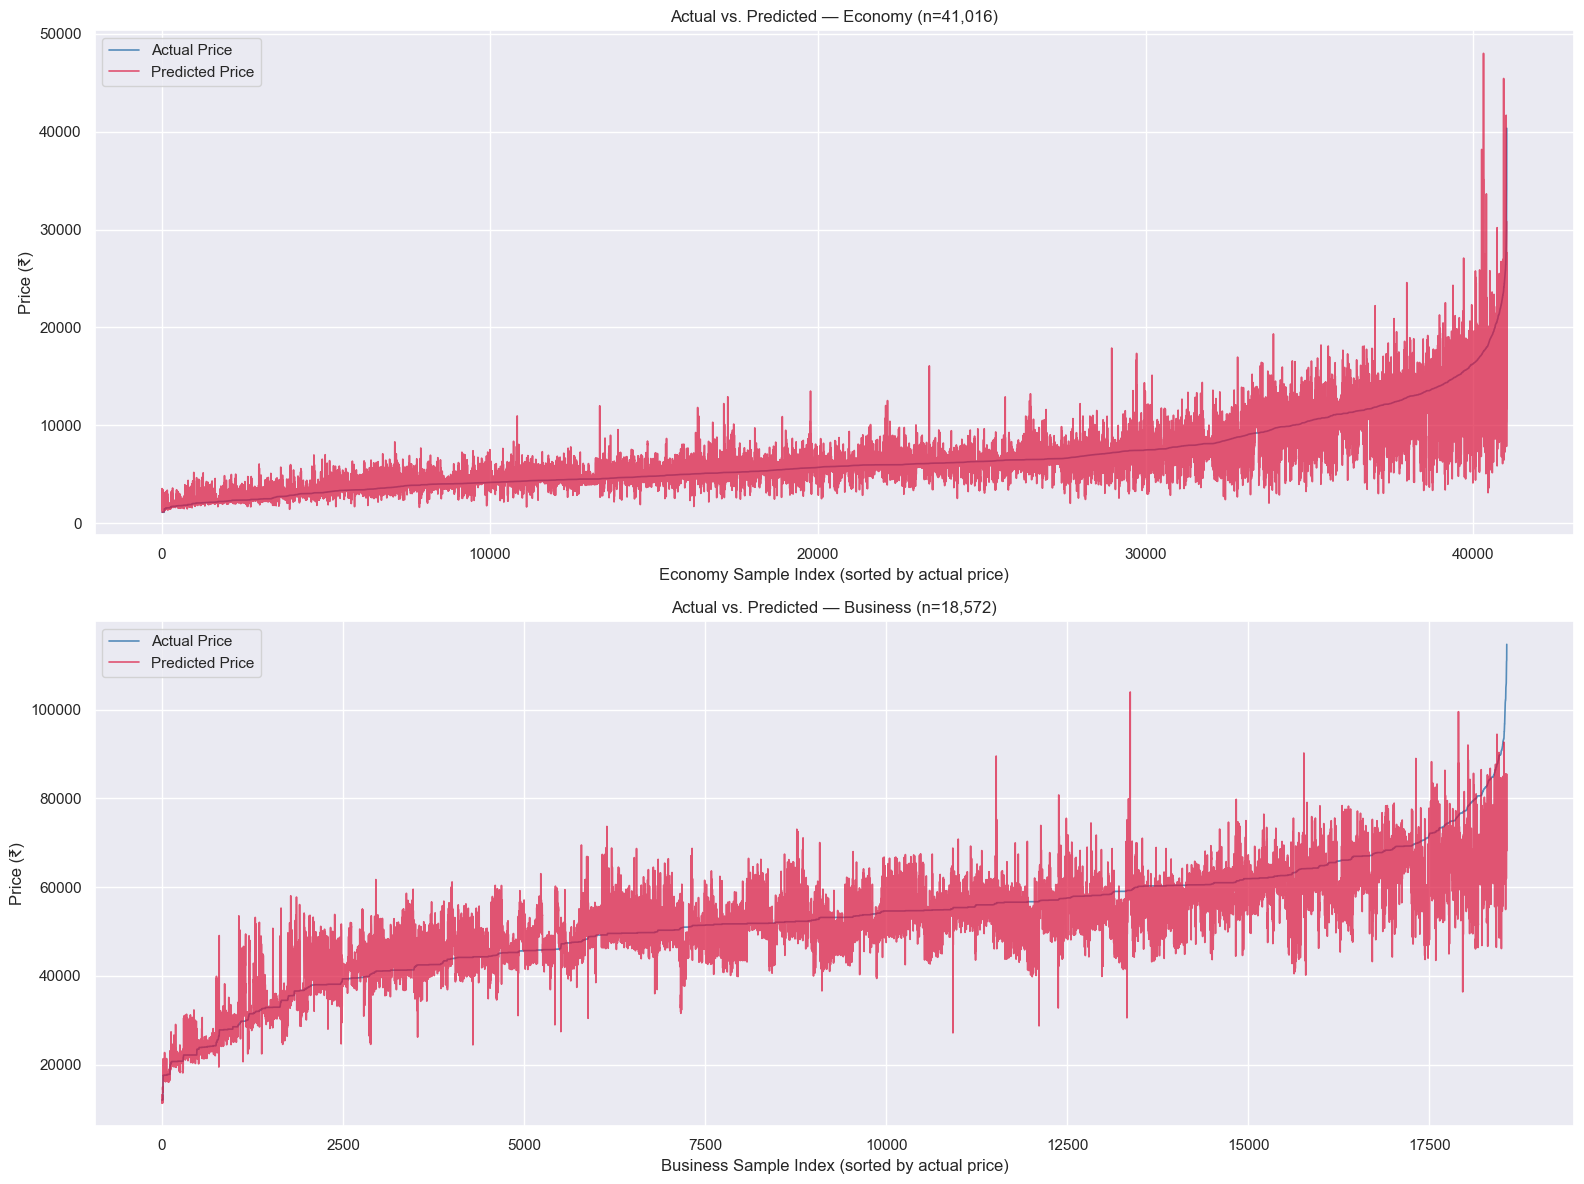

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

for ax, class_name, color_actual, color_pred in [
    (axes[0], 'Economy', 'steelblue', 'crimson'),
    (axes[1], 'Business', 'steelblue', 'crimson'),
]:
    subset = analysis_df[analysis_df['class'] == class_name].sort_values('actual_price').reset_index(drop=True)

    ax.plot(subset.index, subset['actual_price'],
            label='Actual Price', color=color_actual, linewidth=1.2, alpha=0.9)
    ax.plot(subset.index, subset['predicted_price'],
            label='Predicted Price', color=color_pred, linewidth=1.2, alpha=0.7)

    ax.set_xlabel(f'{class_name} Sample Index (sorted by actual price)')
    ax.set_ylabel('Price (₹)')
    ax.set_title(f'Actual vs. Predicted — {class_name} (n={len(subset):,})')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
df= pd.read_csv('data/raw/clean_dataset.csv')
print(df.shape)

(300153, 12)


In [3]:
print("Total rows:", len(df))
print("Duplicates (all columns):", df.duplicated().sum())
print("Duplicates (ignoring Unnamed: 0):", df.drop(columns=['Unnamed: 0']).duplicated().sum())

Total rows: 300153
Duplicates (all columns): 0
Duplicates (ignoring Unnamed: 0): 0


In [11]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def compute_metrics(y_true, y_pred):
    """Compute R2, RMSE, MAE, MAPE for a segment."""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # MAPE = Mean Absolute Percentage Error — shows relative error
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape}


# Compute metrics per class
class_results = []

for class_name in ['Economy', 'Business']:
    subset = analysis_df[analysis_df['class'] == class_name]
    metrics = compute_metrics(subset['actual_price'].values, subset['predicted_price'].values)
    metrics['Segment'] = class_name
    metrics['n_samples'] = len(subset)
    metrics['mean_actual_price'] = subset['actual_price'].mean()
    class_results.append(metrics)

# Overall row for comparison
overall_metrics = compute_metrics(analysis_df['actual_price'].values, analysis_df['predicted_price'].values)
overall_metrics['Segment'] = 'OVERALL'
overall_metrics['n_samples'] = len(analysis_df)
overall_metrics['mean_actual_price'] = analysis_df['actual_price'].mean()
class_results.append(overall_metrics)

# Build summary dataframe
class_summary = pd.DataFrame(class_results)[
    ['Segment', 'n_samples', 'mean_actual_price', 'R2', 'RMSE', 'MAE', 'MAPE (%)']
]

# Format for readability
class_summary_display = class_summary.copy()
class_summary_display['mean_actual_price'] = class_summary_display['mean_actual_price'].map('₹{:,.0f}'.format)
class_summary_display['RMSE'] = class_summary_display['RMSE'].map('₹{:,.0f}'.format)
class_summary_display['MAE'] = class_summary_display['MAE'].map('₹{:,.0f}'.format)
class_summary_display['R2'] = class_summary_display['R2'].map('{:.4f}'.format)
class_summary_display['MAPE (%)'] = class_summary_display['MAPE (%)'].map('{:.2f}%'.format)

print("=" * 80)
print("Segment Analysis by Class")
print("=" * 80)
print(class_summary_display.to_string(index=False))

Segment Analysis by Class
 Segment  n_samples mean_actual_price     R2   RMSE    MAE MAPE (%)
 Economy      41016            ₹6,564 0.7738 ₹1,770 ₹1,006   14.43%
Business      18572           ₹52,441 0.7249 ₹6,813 ₹4,757    8.88%
 OVERALL      59588           ₹20,863 0.9676 ₹4,077 ₹2,175   12.70%


In [12]:
# Define price buckets
price_bins = [0, 10000, 25000, 50000, 75000, np.inf]
bucket_labels = ['₹0–10k', '₹10k–25k', '₹25k–50k', '₹50k–75k', '₹75k+']

# Assign each test sample to a bucket based on its actual price
analysis_df['price_bucket'] = pd.cut(
    analysis_df['actual_price'],
    bins=price_bins,
    labels=bucket_labels,
    include_lowest=True,
)

# Compute metrics per bucket
bucket_results = []

for bucket in bucket_labels:
    subset = analysis_df[analysis_df['price_bucket'] == bucket]
    if len(subset) == 0:
        continue
    metrics = compute_metrics(subset['actual_price'].values, subset['predicted_price'].values)
    metrics['Price Bucket'] = bucket
    metrics['n_samples'] = len(subset)
    metrics['mean_actual_price'] = subset['actual_price'].mean()
    bucket_results.append(metrics)

# Build summary dataframe
bucket_summary = pd.DataFrame(bucket_results)[
    ['Price Bucket', 'n_samples', 'mean_actual_price', 'R2', 'RMSE', 'MAE', 'MAPE (%)']
]

# Format for readability
bucket_summary_display = bucket_summary.copy()
bucket_summary_display['mean_actual_price'] = bucket_summary_display['mean_actual_price'].map('₹{:,.0f}'.format)
bucket_summary_display['RMSE'] = bucket_summary_display['RMSE'].map('₹{:,.0f}'.format)
bucket_summary_display['MAE'] = bucket_summary_display['MAE'].map('₹{:,.0f}'.format)
bucket_summary_display['R2'] = bucket_summary_display['R2'].map('{:.4f}'.format)
bucket_summary_display['MAPE (%)'] = bucket_summary_display['MAPE (%)'].map('{:.2f}%'.format)

print("=" * 80)
print("Segment Analysis by Price Bucket")
print("=" * 80)
print(bucket_summary_display.to_string(index=False))

Segment Analysis by Price Bucket
Price Bucket  n_samples mean_actual_price      R2    RMSE     MAE MAPE (%)
      ₹0–10k      34486            ₹5,248  0.6932  ₹1,049    ₹710   13.79%
    ₹10k–25k       7215           ₹14,235  0.2051  ₹3,424  ₹2,370   16.44%
    ₹25k–50k       6161           ₹41,564  0.2334  ₹5,499  ₹3,936    9.92%
    ₹50k–75k      11011           ₹58,503 -0.0993  ₹6,252  ₹4,722    7.95%
       ₹75k+        715           ₹82,828 -7.1778 ₹18,751 ₹16,466   19.64%


In [13]:
print("\n" + "=" * 80)
print("COMBINED EVALUATION SUMMARY")
print("=" * 80)
print("\n--- By Class ---\n")
print(class_summary_display.to_string(index=False))
print("\n--- By Price Bucket ---\n")
print(bucket_summary_display.to_string(index=False))

print("\n" + "=" * 80)
print("Key Questions to Answer from These Tables:")
print("=" * 80)
print("1. Is Business MAE >> Economy MAE? (Expected — higher prices = larger absolute errors)")
print("2. Is Business MAPE similar to Economy MAPE? (Expected if log-space training worked fairly)")
print("3. Which price bucket has the worst MAPE? (Reveals where the model struggles)")
print("4. Does MAPE grow at the extreme price buckets? (Indicates edge-of-distribution weakness)")


COMBINED EVALUATION SUMMARY

--- By Class ---

 Segment  n_samples mean_actual_price     R2   RMSE    MAE MAPE (%)
 Economy      41016            ₹6,564 0.7738 ₹1,770 ₹1,006   14.43%
Business      18572           ₹52,441 0.7249 ₹6,813 ₹4,757    8.88%
 OVERALL      59588           ₹20,863 0.9676 ₹4,077 ₹2,175   12.70%

--- By Price Bucket ---

Price Bucket  n_samples mean_actual_price      R2    RMSE     MAE MAPE (%)
      ₹0–10k      34486            ₹5,248  0.6932  ₹1,049    ₹710   13.79%
    ₹10k–25k       7215           ₹14,235  0.2051  ₹3,424  ₹2,370   16.44%
    ₹25k–50k       6161           ₹41,564  0.2334  ₹5,499  ₹3,936    9.92%
    ₹50k–75k      11011           ₹58,503 -0.0993  ₹6,252  ₹4,722    7.95%
       ₹75k+        715           ₹82,828 -7.1778 ₹18,751 ₹16,466   19.64%

Key Questions to Answer from These Tables:
1. Is Business MAE >> Economy MAE? (Expected — higher prices = larger absolute errors)
2. Is Business MAPE similar to Economy MAPE? (Expected if log-space train